# Alzheimer's Disease Brain MRI — Multi-Class Tissue Segmentation
## VGG16 + UNet++ | 4-Class (Background / CSF / Grey Matter / White Matter) | IBSR Dataset

**Dataset:** Internet Brain Segmentation Repository (IBSR) — 18 subjects, expert-annotated tri-class tissue segmentation (`segTRI`).

**Architecture:** UNet++ (Nested UNet) replaces plain UNet skip connections with dense nested sub-networks between encoder and decoder, enabling multi-scale feature re-use and stronger gradient flow.

**Why multi-class directly (no binary step):** The binary-then-multiclass pipeline was already validated on OASIS-1. Since IBSR's `segTRI` masks use the same 4-label convention (0=background, 1=CSF, 2=GM, 3=WM), we go directly to multi-class here.

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

**Note on CSF class:** IBSR's CSF label is far sparser (~0.17% of voxels) than OASIS-1's (~7.5%) — expect CSF IoU to be a harder, noisier metric here purely due to extreme class imbalance, not a pipeline issue.

## 1. Import Libraries

In [1]:
import os
import re
import cv2
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

2026-06-29 09:53:08.621472: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782726788.828192      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782726788.883660      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782726789.318294      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782726789.318333      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782726789.318336      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration & Extraction

In [2]:
# ─── Paths ────────────────────────────────────────────────────────────────────
IBSR_TGZ_PATH = '/kaggle/input/datasets/mahi789/ibsr-datasett/IBSR_V2.0_nifti_stripped.tgz'
EXTRACT_DIR   = '/kaggle/working/ibsr_extracted'
IBSR_ROOT     = os.path.join(EXTRACT_DIR, 'IBSR_nifti_stripped')

PROCESSED_DIR   = 'ibsr_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15
NUM_CLASSES = 4   # 0=background, 1=CSF, 2=Grey Matter, 3=White Matter
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

print('Config set ✓')

Config set ✓


In [3]:
# ─── Extract the .tgz if not already done ─────────────────────────────────────
if not os.path.exists(IBSR_ROOT):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print('Extracting IBSR archive...')
    with tarfile.open(IBSR_TGZ_PATH, 'r:gz') as tar:
        tar.extractall(path=EXTRACT_DIR)
    print('Extraction done ✓')
else:
    print('Already extracted ✓')

subject_folders = sorted([
    d for d in os.listdir(IBSR_ROOT)
    if os.path.isdir(os.path.join(IBSR_ROOT, d)) and d.startswith('IBSR_')
])
print(f'Found {len(subject_folders)} subjects: {subject_folders}')

Extracting IBSR archive...
Extraction done ✓
Found 18 subjects: ['IBSR_01', 'IBSR_02', 'IBSR_03', 'IBSR_04', 'IBSR_05', 'IBSR_06', 'IBSR_07', 'IBSR_08', 'IBSR_09', 'IBSR_10', 'IBSR_11', 'IBSR_12', 'IBSR_13', 'IBSR_14', 'IBSR_15', 'IBSR_16', 'IBSR_17', 'IBSR_18']


## 3. Extract 2D Slices — Keep All 4 Tissue Labels

In [4]:
def make_dir(path):
    os.makedirs(path, exist_ok=True)

for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    make_dir(d)

print('Directories ready ✓')

Directories ready ✓


In [5]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices_ibsr(subject_dir, subject_name, img_out, mask_out, step=1):
    """
    IBSR file naming: <subject>_ana_strip.nii.gz  (skull-stripped brain)
                       <subject>_segTRI_ana.nii    (4-class tissue mask)
    Both are (256, 128, 256, 1) — squeeze the trailing singleton dim.
    Mask labels kept as raw integers 0/1/2/3.
    """
    brain_path = os.path.join(subject_dir, f'{subject_name}_ana_strip.nii.gz')
    seg_path   = os.path.join(subject_dir, f'{subject_name}_segTRI_ana.nii')

    if not os.path.exists(brain_path) or not os.path.exists(seg_path):
        print(f'  Skipping {subject_name} — missing file(s)')
        return 0

    brain_vol = np.squeeze(nib.load(brain_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = np.round(seg_sl).astype(np.uint8)
        mask_arr = np.clip(mask_arr, 0, NUM_CLASSES - 1)

        fname = f'{subject_name}_sl{i:03d}.png'
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

total_slices = 0
for subj_name in tqdm(subject_folders, desc='Extracting slices'):
    subj_dir = os.path.join(IBSR_ROOT, subj_name)
    total_slices += extract_slices_ibsr(subj_dir, subj_name, IMAGE_FOLDER, MASK_FOLDER, step=1)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')
print('Note: step=1 (every slice) since IBSR only has 18 subjects.')

Extracting slices:   0%|          | 0/18 [00:00<?, ?it/s]

  Skipping IBSR_02 — missing file(s)
  Skipping IBSR_03 — missing file(s)
  Skipping IBSR_04 — missing file(s)
  Skipping IBSR_05 — missing file(s)
  Skipping IBSR_07 — missing file(s)
  Skipping IBSR_08 — missing file(s)
  Skipping IBSR_09 — missing file(s)
  Skipping IBSR_10 — missing file(s)
  Skipping IBSR_11 — missing file(s)
  Skipping IBSR_12 — missing file(s)
  Skipping IBSR_13 — missing file(s)
  Skipping IBSR_14 — missing file(s)
  Skipping IBSR_15 — missing file(s)
  Skipping IBSR_16 — missing file(s)
  Skipping IBSR_17 — missing file(s)
  Skipping IBSR_18 — missing file(s)

Total slices extracted : 236
Images saved           : 236
Masks  saved           : 236
Note: step=1 (every slice) since IBSR only has 18 subjects.


## 4. Verify Label Distribution & Visualize

In [6]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


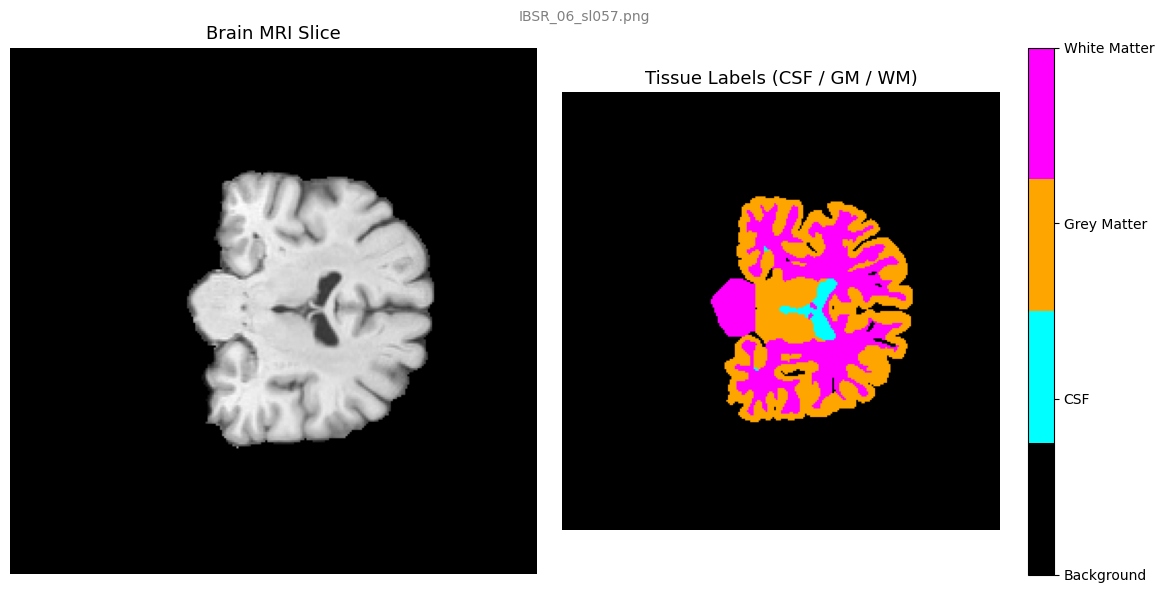

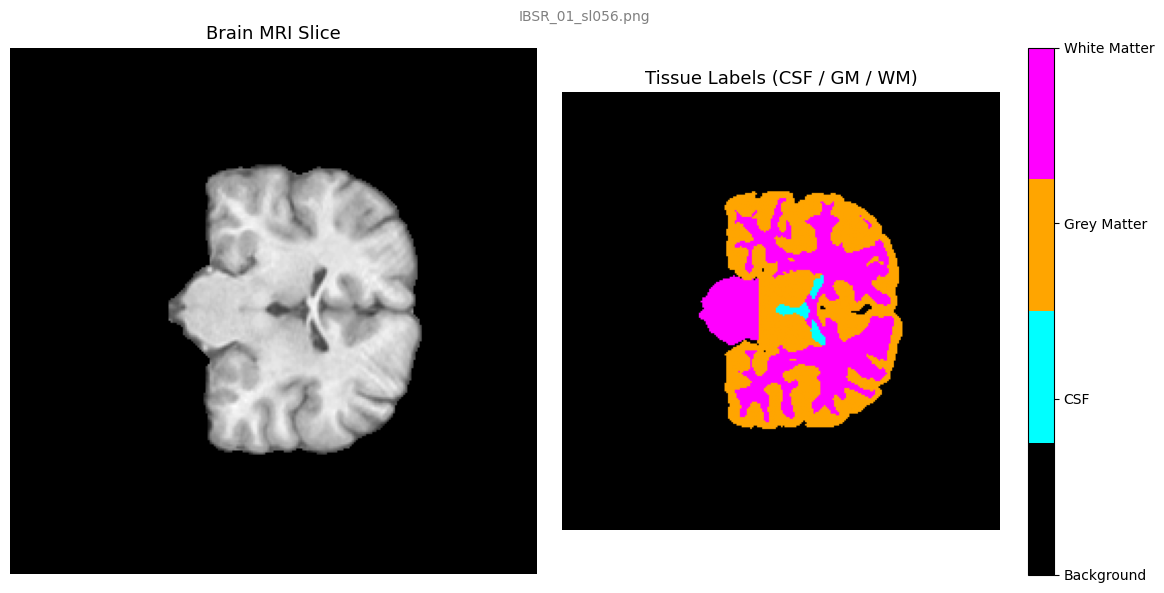

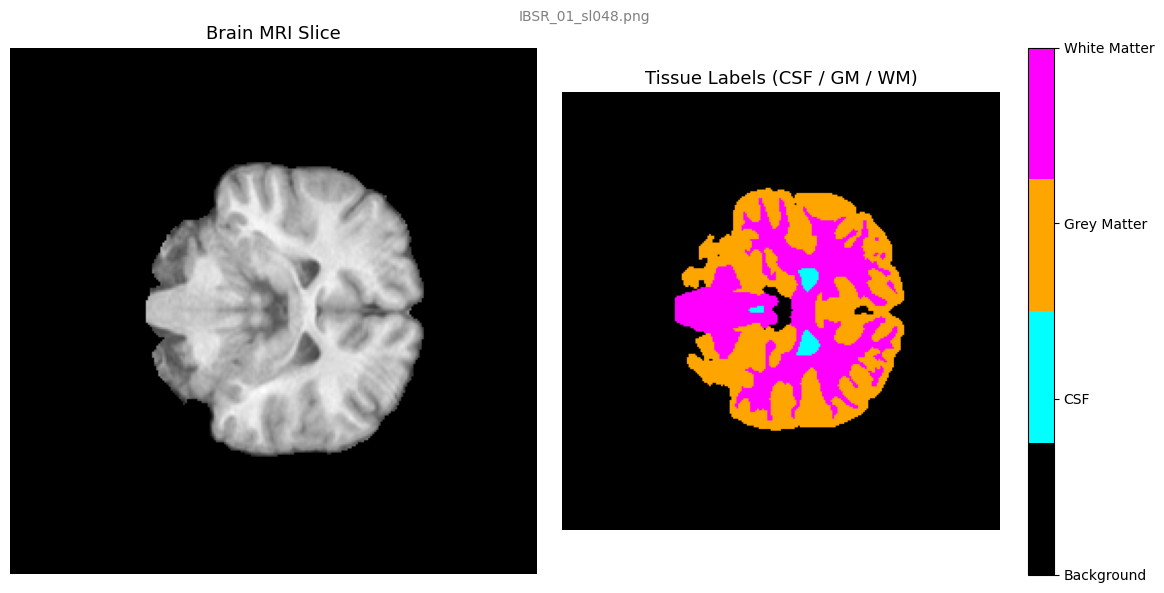

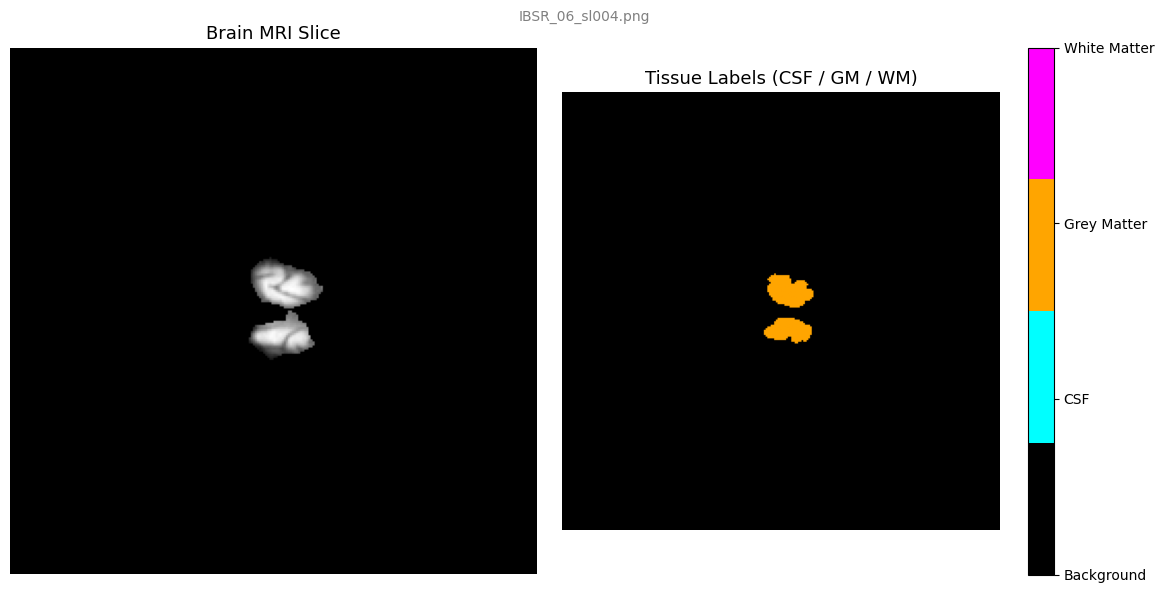

In [7]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample_multiclass(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample_multiclass(random.choice(all_images))

## 5. Train / Test Split

In [8]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 200  |  Test: 36


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline — one-hot encoded masks

In [9]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

I0000 00:00:1782726811.694439      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 4)


## 7. Model — VGG16 Encoder + UNet++ Decoder, 4-class softmax output

### UNet++ Architecture

UNet++ (Zhou et al., 2018) replaces the single long skip connections of UNet with **dense nested sub-networks**:

- Each node `X^{i,j}` receives feature maps from:
  - All previous nodes in the same encoder level: `X^{i,0..j-1}` (horizontal dense connections)
  - The upsampled output from one level deeper: `X^{i+1,j-1}` (vertical / decoder path)
- This creates **progressive feature aggregation** across multiple semantic scales.
- Deep supervision can optionally be applied at each depth output (not used here).

```
Encoder (VGG16)         Dense Nodes                         Output
X00  ─────────────── X01 ────── X02 ────── X03 ────── X04  → softmax
X10  ──────────────────────── X11 ────── X12 ────── X13
X20  ──────────────────────────────────── X21 ────── X22
X30  ──────────────────────────────────────────────── X31
X40  (bottleneck)
```


In [10]:
def conv_block(x, filters, name_prefix):
    """Standard double-conv block with BN + ReLU."""
    x = Conv2D(filters, (3, 3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3, 3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x


def unetpp_node(up_input, skip_inputs, filters, name_prefix):
    """
    UNet++ dense node X^{i,j}:
      - up_input    : upsampled tensor from X^{i+1, j-1}  (vertical path)
      - skip_inputs : list of X^{i, 0..j-1}               (horizontal dense path)
      - filters     : number of conv filters
    """
    x = UpSampling2D((2, 2), name=f'{name_prefix}_up')(up_input)
    x = concatenate([x] + skip_inputs, name=f'{name_prefix}_cat')
    x = Dropout(0.2, name=f'{name_prefix}_drop')(x)
    x = conv_block(x, filters, name_prefix)
    return x


def build_vgg16_unetpp_multiclass(input_shape=(224, 224, 3), num_classes=4, freeze_encoder=True):
    """
    VGG16 encoder with UNet++ nested decoder.

    Encoder nodes (VGG16 feature map outputs):
      X00 = block1_conv2  (224x224,  64 ch)
      X10 = block2_conv2  (112x112, 128 ch)
      X20 = block3_conv3  ( 56x56,  256 ch)
      X30 = block4_conv3  ( 28x28,  512 ch)
      X40 = block5_conv3  ( 14x14,  512 ch)  <- bottleneck

    Dense decoder nodes:
      Depth 1 : X31, X21, X11, X01
      Depth 2 : X22, X12, X02
      Depth 3 : X13, X03
      Depth 4 : X04  <- final output node
    """
    inputs = Input(shape=input_shape, name='input')
    base   = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base.layers:
            layer.trainable = False

    # ── Encoder nodes ─────────────────────────────────────────────────────────
    X00 = base.get_layer('block1_conv2').output   # 224x224, 64
    X10 = base.get_layer('block2_conv2').output   # 112x112, 128
    X20 = base.get_layer('block3_conv3').output   #  56x56,  256
    X30 = base.get_layer('block4_conv3').output   #  28x28,  512
    X40 = base.get_layer('block5_conv3').output   #  14x14,  512

    # ── Depth 1 — one step up from each encoder level ─────────────────────────
    X31 = unetpp_node(X40, [X30],        512, 'X31')
    X21 = unetpp_node(X30, [X20],        256, 'X21')
    X11 = unetpp_node(X20, [X10],        128, 'X11')
    X01 = unetpp_node(X10, [X00],         64, 'X01')

    # ── Depth 2 — dense connections accumulate ────────────────────────────────
    X22 = unetpp_node(X31, [X20, X21],   256, 'X22')
    X12 = unetpp_node(X21, [X10, X11],   128, 'X12')
    X02 = unetpp_node(X11, [X00, X01],    64, 'X02')

    # ── Depth 3 ───────────────────────────────────────────────────────────────
    X13 = unetpp_node(X22, [X10, X11, X12], 128, 'X13')
    X03 = unetpp_node(X12, [X00, X01, X02],  64, 'X03')

    # ── Depth 4 — final decoder node ──────────────────────────────────────────
    X04 = unetpp_node(X13, [X00, X01, X02, X03], 64, 'X04')

    # ── Output head ───────────────────────────────────────────────────────────
    output = Conv2D(num_classes, (1, 1), activation='softmax', name='output')(X04)

    model = Model(inputs=inputs, outputs=output, name='VGG16_UNetPP_MultiClass')
    return model


model = build_vgg16_unetpp_multiclass(
    input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES, freeze_encoder=True
)
print('Model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model built ✓
Total parameters      : 30,140,740
Trainable parameters  : 15,419,396


## 8. Custom Metrics & Loss — categorical versions

In [11]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return K.mean(dice_per_class)


def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)


def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    iou_per_class = (intersection + smooth) / (total + smooth)
    return K.mean(iou_per_class)


def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    intersection = K.sum(t * p)
    union = K.sum(t) + K.sum(p) - intersection
    return (intersection + smooth) / (union + smooth)


def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    intersection = K.sum(t * p)
    union = K.sum(t) + K.sum(p) - intersection
    return (intersection + smooth) / (union + smooth)


def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    intersection = K.sum(t * p)
    union = K.sum(t) + K.sum(p) - intersection
    return (intersection + smooth) / (union + smooth)


def pixel_accuracy_multiclass(y_true, y_pred):
    true_labels = K.argmax(y_true, axis=-1)
    pred_labels = K.argmax(y_pred, axis=-1)
    correct = K.cast(K.equal(true_labels, pred_labels), K.floatx())
    return K.mean(correct)


def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass, pixel_accuracy_multiclass,
             csf_iou, gm_iou, wm_iou]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [12]:
model.summary()

try:
    tf.keras.utils.plot_model(
        model, to_file='vgg16_unetpp_multiclass_ibsr_architecture.png',
        show_shapes=True, show_layer_names=True, rankdir='TB', dpi=64
    )
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:150])

Model: "VGG16_UNetPP_MultiClass"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 30,140,740 (114.98 MB)

 Trainable params: 15,419,396 (58.82 MB)

 Non-trainable params: 14,721,344 (56.16 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [13]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)


def colorize_mask(label_map):
    colors = np.array([[0,0,0], [0,255,255], [255,165,0], [255,0,255]], dtype=np.uint8)
    label_map = np.array(label_map).astype(int)
    return colors[label_map]


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            gt_labels   = decode_mask(masks[i]).numpy()
            pred_labels = decode_mask(preds[i]).numpy()
            fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(gt_labels));   axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(pred_labels)); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg16unetpp_multiclass_ibsr.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]

print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


I0000 00:00:1782726820.077992     132 service.cc:152] XLA service 0x7c4884009cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782726820.078025     132 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782726820.541725     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782726850.577296     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


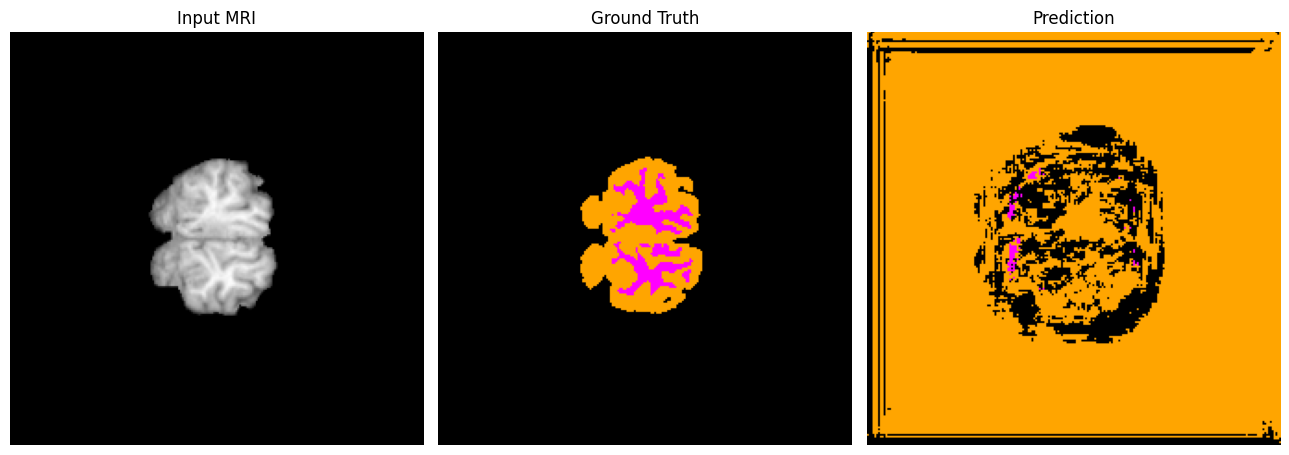

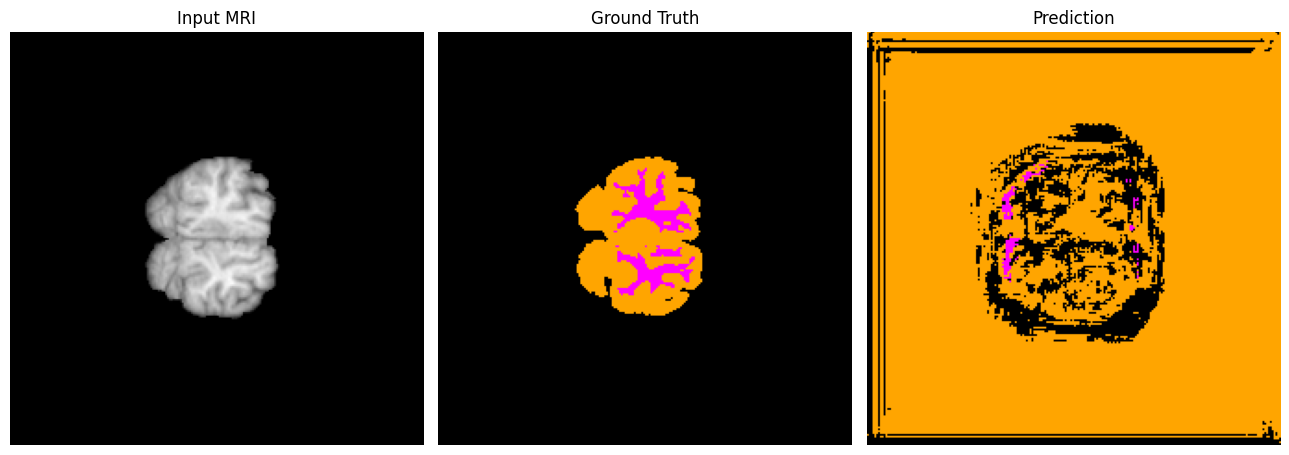

In [14]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 12
Validation steps : 2
Epoch 1/100


2026-06-29 09:54:33.686361: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng2{k2=3,k3=0} for conv %cudnn-conv-bw-input.17 = (f32[16,384,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,224,224]{3,2,1,0} %bitcast.51371, f32[64,384,3,3]{3,2,1,0} %bitcast.44074), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/VGG16_UNetPP_MultiClass_1/X04_c1_1/convolution/Conv2DBackpropInput" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-29 09:54:33.751748: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.065

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - csf_iou: 6.7266e-04 - dice_coefficient_multiclass: 0.2396 - gm_iou: 0.1787 - iou_score_multiclass: 0.1571 - loss: 1.8408 - pixel_accuracy_multiclass: 0.6232 - wm_iou: 0.0547
Epoch 1: val_iou_score_multiclass improved from None to 0.02564, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 1: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - csf_iou: 0.0010 - dice_coefficient_multiclass: 0.2845 - gm_iou: 0.1928 - iou_score_multiclass: 0.1917 - loss: 1.6298 - pixel_accuracy_multiclass: 0.7553 - wm_iou: 0.1104 - val_csf_iou: 2.9468e-05 - val_dice_coefficient_multiclass: 0.0466 - val_gm_iou: 0.1003 - val_iou_score_multiclass: 0.0256 - val_loss: 10.0470 - val_pixel_accuracy_multiclass: 0.0931 - val_wm_iou: 0.0015 - learning_rate: 1.0000e-04
Epoch 2/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 8:50 48s/step - csf_iou: 1.6059e-05 - dice_coefficient_multiclass: 0.1978 - gm_iou: 0.0656 - i

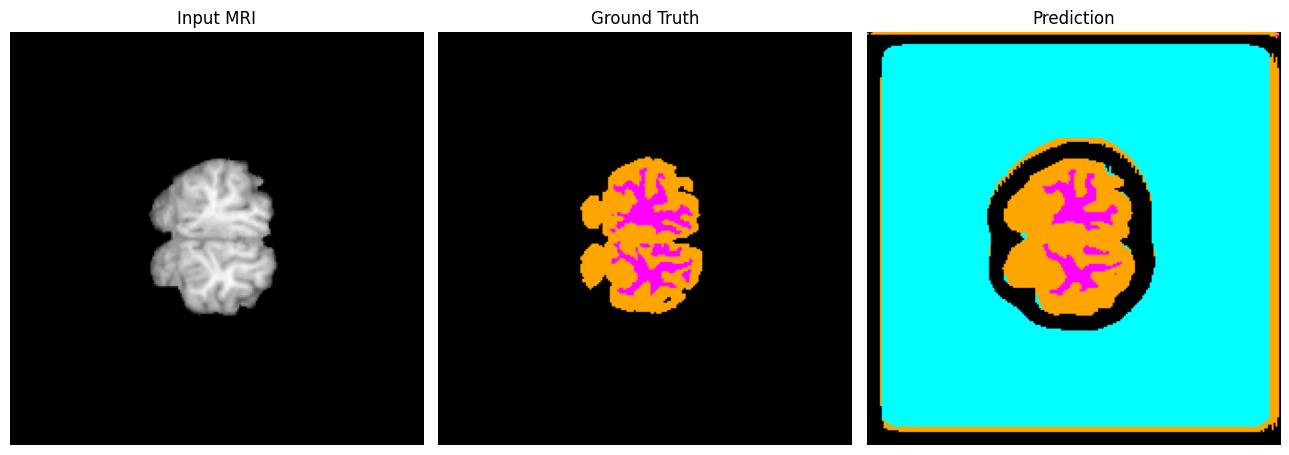

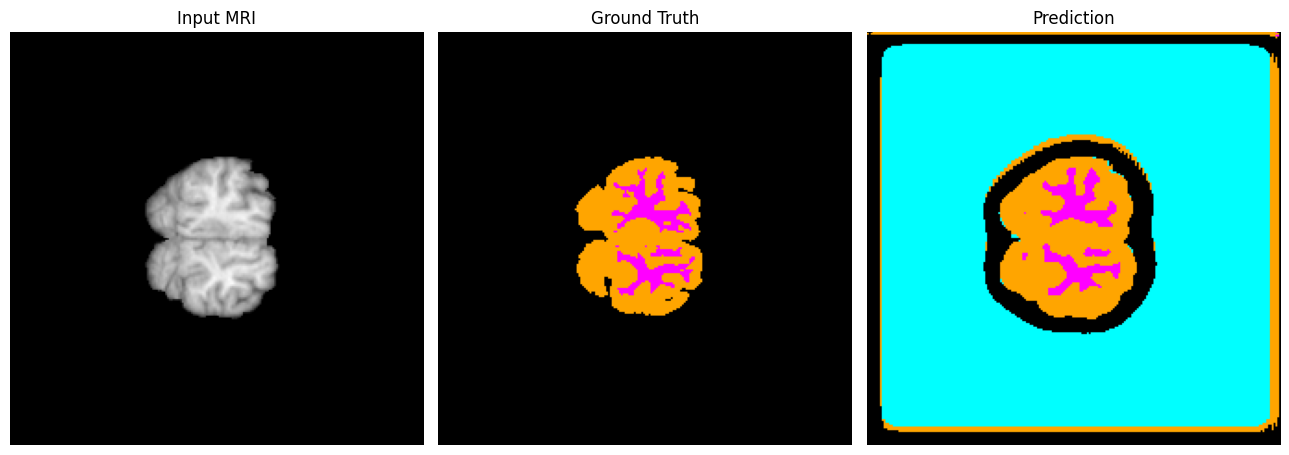

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.18165 to 0.18938, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 10: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 672ms/step - csf_iou: 2.1882e-05 - dice_coefficient_multiclass: 0.2703 - gm_iou: 0.1103 - iou_score_multiclass: 0.2052 - loss: 1.1743 - pixel_accuracy_multiclass: 0.9900 - wm_iou: 0.0426 - val_csf_iou: 0.0024 - val_dice_coefficient_multiclass: 0.2998 - val_gm_iou: 0.3006 - val_iou_score_multiclass: 0.1894 - val_loss: 1.9293 - val_pixel_accuracy_multiclass: 0.2878 - val_wm_iou: 0.1669 - learning_rate: 1.0000e-04
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - csf_iou: 0.0106 - dice_coefficient_multiclass: 0.5090 - gm_iou: 0.4281 - iou_score_multiclass: 0.4056 - loss: 0.7441 - pixel_accuracy_multiclass: 0.9769 - wm_iou: 0.3844
Epoch 11: val_iou_score_multiclass improved from 0.18938 to 0.27023, saving model to best_

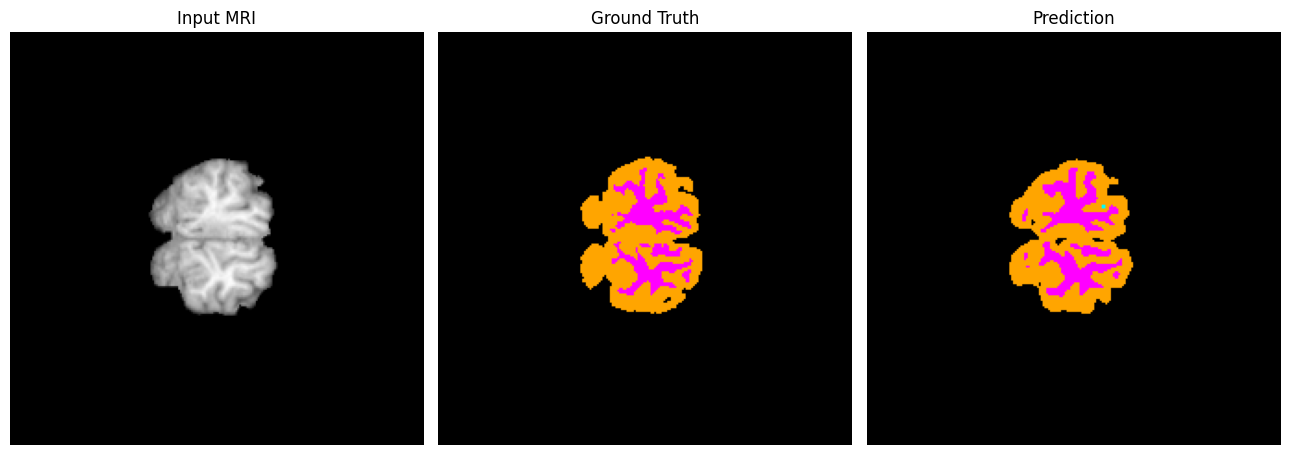

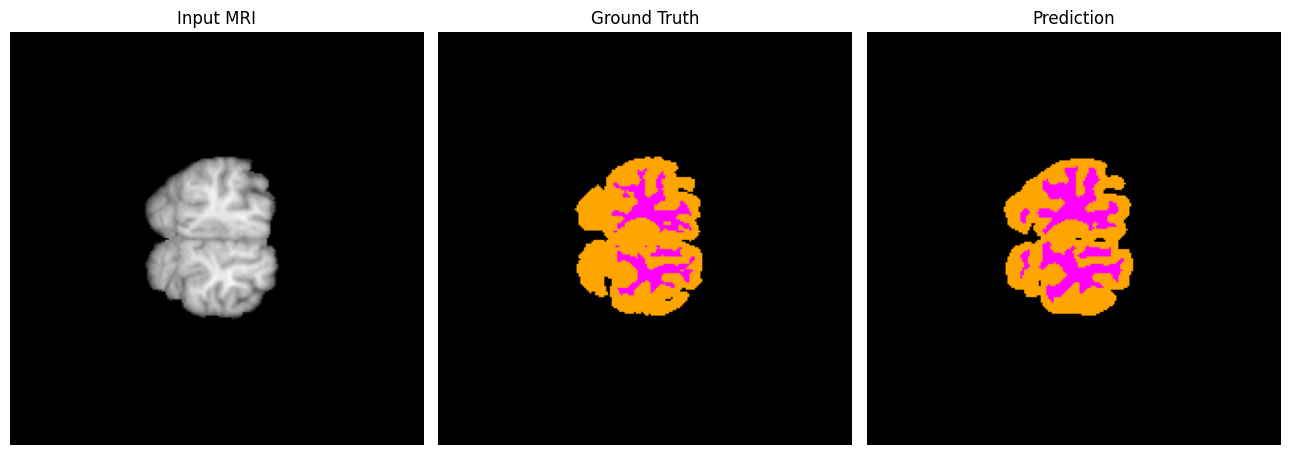

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass improved from 0.44503 to 0.44685, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 20: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 675ms/step - csf_iou: 4.0669e-05 - dice_coefficient_multiclass: 0.3554 - gm_iou: 0.2020 - iou_score_multiclass: 0.2838 - loss: 0.8412 - pixel_accuracy_multiclass: 0.9938 - wm_iou: 0.0952 - val_csf_iou: 0.0249 - val_dice_coefficient_multiclass: 0.5585 - val_gm_iou: 0.4931 - val_iou_score_multiclass: 0.4469 - val_loss: 0.6847 - val_pixel_accuracy_multiclass: 0.9801 - val_wm_iou: 0.4617 - learning_rate: 1.0000e-04
Epoch 21/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - csf_iou: 0.0403 - dice_coefficient_multiclass: 0.6000 - gm_iou: 0.5646 - iou_score_multiclass: 0.5030 - loss: 0.5396 - pixel_accuracy_multiclass: 0.9818 - wm_iou: 0.5129
Epoch 21: val_iou_score_multiclass improved from 0.44685 to 0.45585, saving model to best_

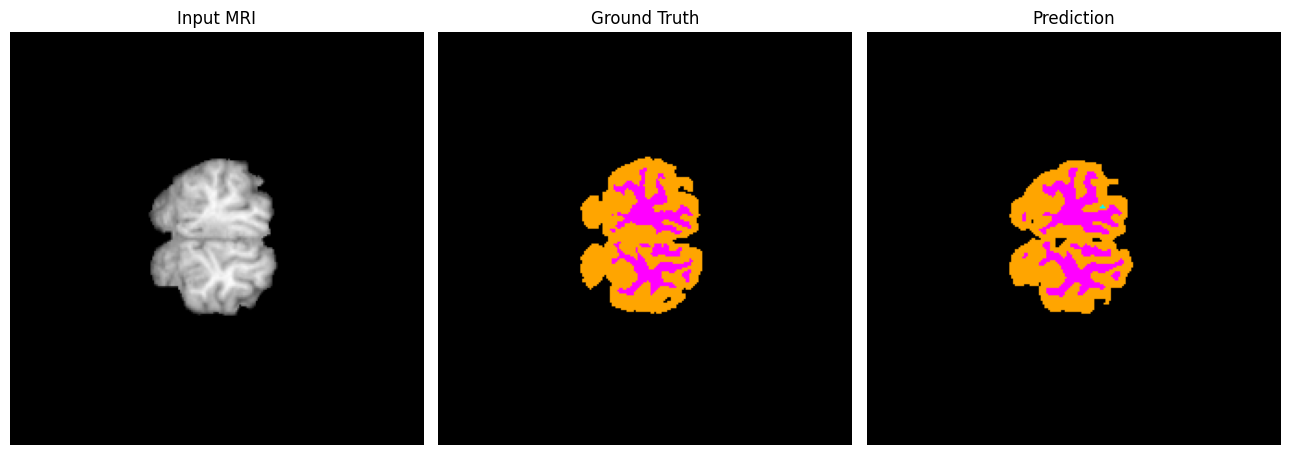

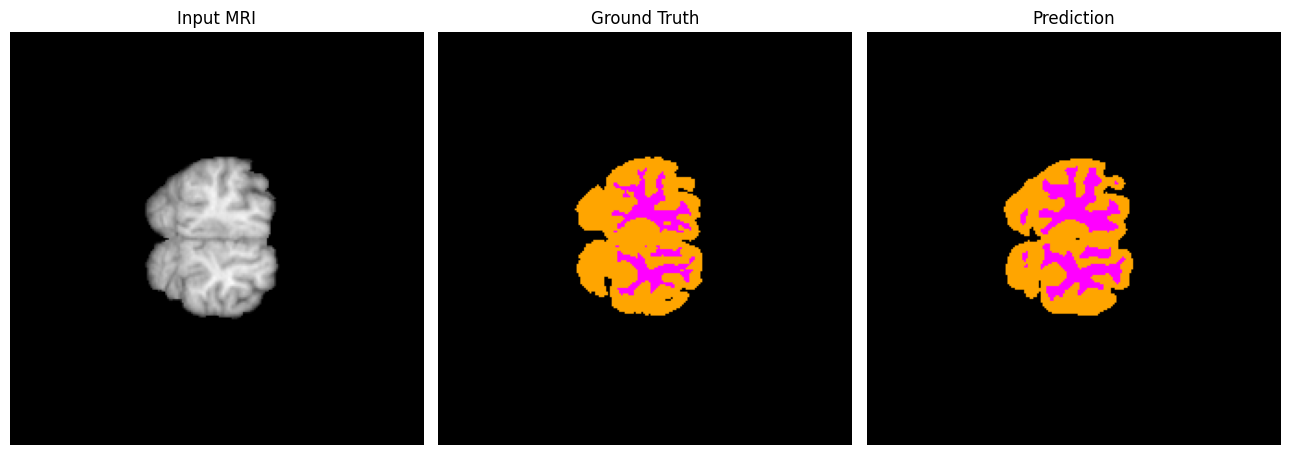

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass did not improve from 0.53589
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 564ms/step - csf_iou: 5.7261e-05 - dice_coefficient_multiclass: 0.3961 - gm_iou: 0.2489 - iou_score_multiclass: 0.3181 - loss: 0.7463 - pixel_accuracy_multiclass: 0.9944 - wm_iou: 0.1422 - val_csf_iou: 0.0511 - val_dice_coefficient_multiclass: 0.6331 - val_gm_iou: 0.5948 - val_iou_score_multiclass: 0.5343 - val_loss: 0.5027 - val_pixel_accuracy_multiclass: 0.9804 - val_wm_iou: 0.5898 - learning_rate: 1.0000e-04
Epoch 31/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - csf_iou: 0.0627 - dice_coefficient_multiclass: 0.6361 - gm_iou: 0.6189 - iou_score_multiclass: 0.5428 - loss: 0.4732 - pixel_accuracy_multiclass: 0.9829 - wm_iou: 0.5692
Epoch 31: val_iou_score_multiclass improved from 0.53589 to 0.54991, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 31: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

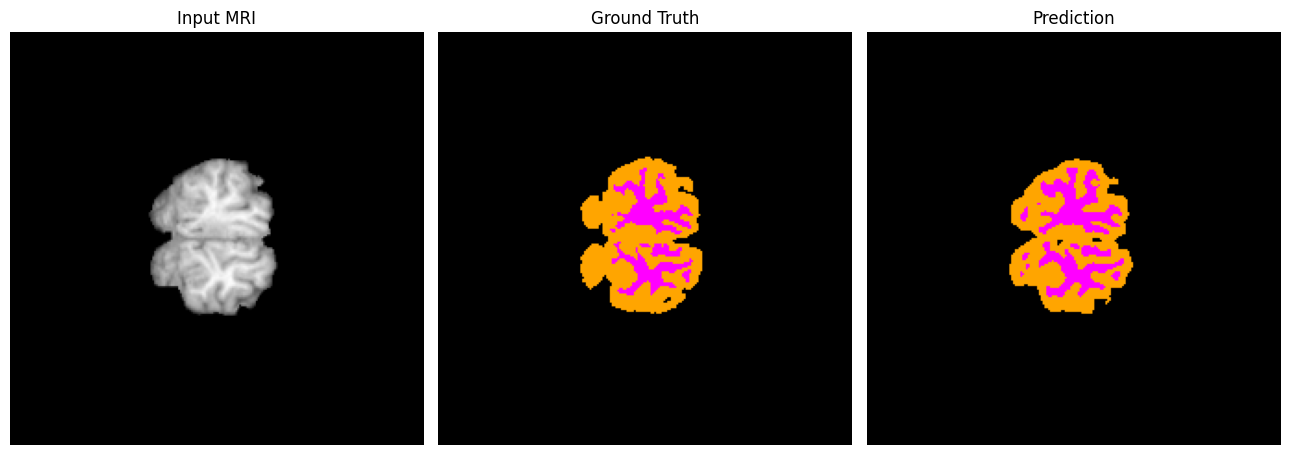

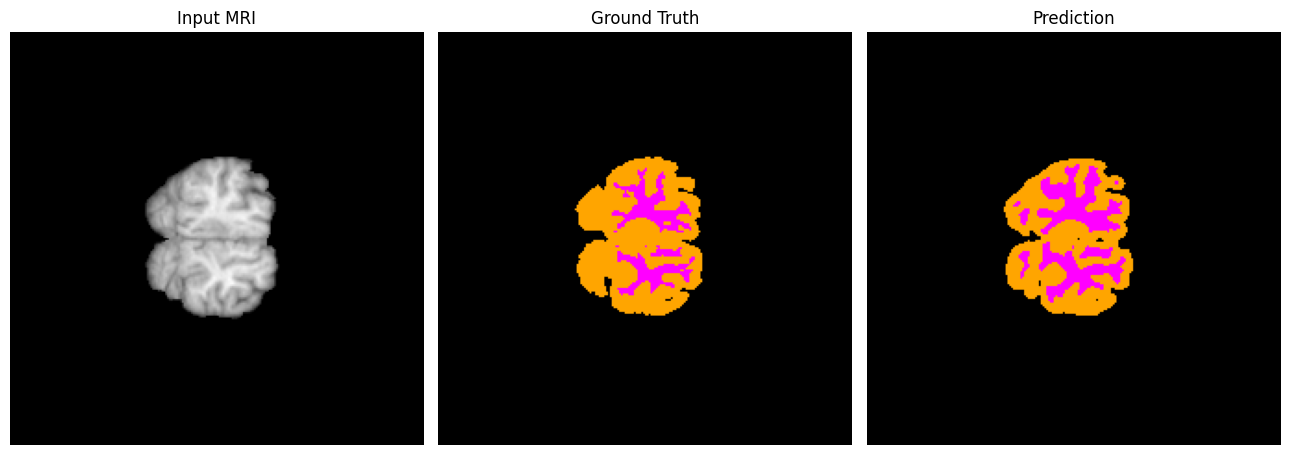

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.59157
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 566ms/step - csf_iou: 7.4399e-05 - dice_coefficient_multiclass: 0.4254 - gm_iou: 0.2907 - iou_score_multiclass: 0.3435 - loss: 0.6861 - pixel_accuracy_multiclass: 0.9952 - wm_iou: 0.1766 - val_csf_iou: 0.0928 - val_dice_coefficient_multiclass: 0.6801 - val_gm_iou: 0.6509 - val_iou_score_multiclass: 0.5859 - val_loss: 0.4203 - val_pixel_accuracy_multiclass: 0.9790 - val_wm_iou: 0.6558 - learning_rate: 1.0000e-04
Epoch 41/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - csf_iou: 0.0831 - dice_coefficient_multiclass: 0.6626 - gm_iou: 0.6604 - iou_score_multiclass: 0.5728 - loss: 0.4273 - pixel_accuracy_multiclass: 0.9845 - wm_iou: 0.6095
Epoch 41: val_iou_score_multiclass improved from 0.59157 to 0.61075, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 41: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

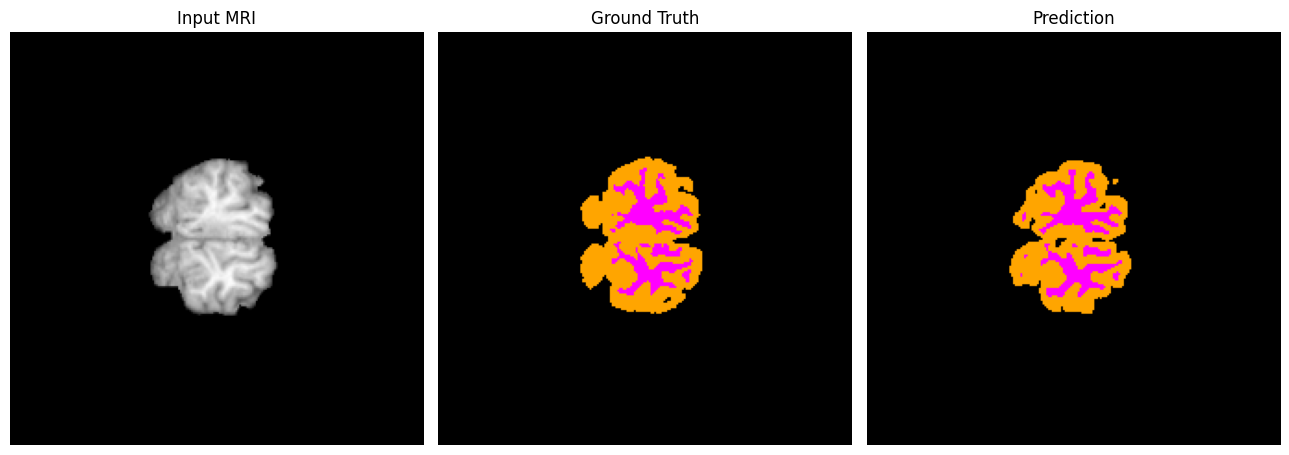

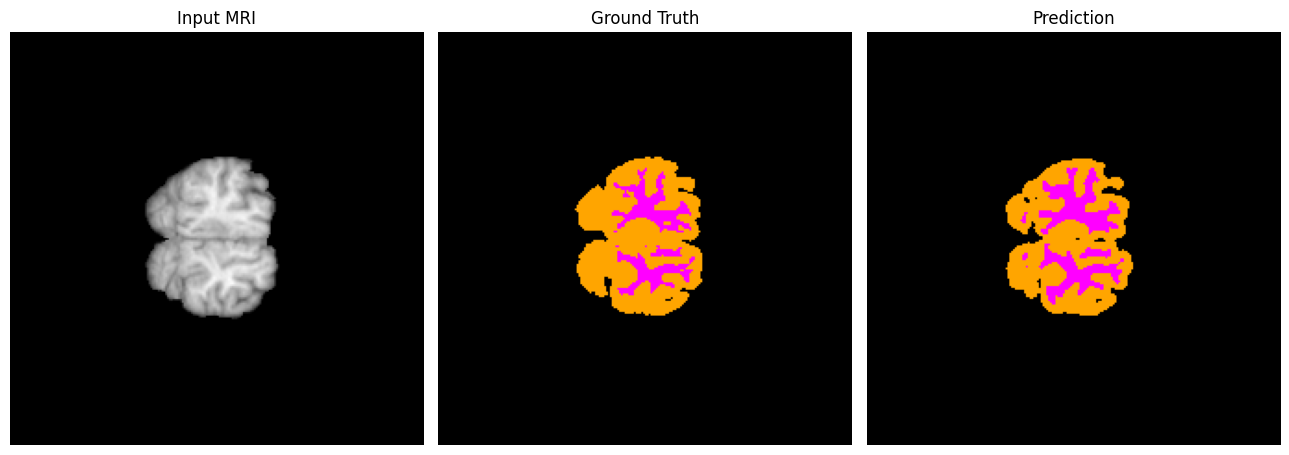

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass did not improve from 0.63129
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - csf_iou: 9.3855e-05 - dice_coefficient_multiclass: 0.4476 - gm_iou: 0.3290 - iou_score_multiclass: 0.3637 - loss: 0.6406 - pixel_accuracy_multiclass: 0.9957 - wm_iou: 0.2008 - val_csf_iou: 0.1395 - val_dice_coefficient_multiclass: 0.7209 - val_gm_iou: 0.6992 - val_iou_score_multiclass: 0.6299 - val_loss: 0.3559 - val_pixel_accuracy_multiclass: 0.9806 - val_wm_iou: 0.7224 - learning_rate: 1.0000e-04
Epoch 51/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - csf_iou: 0.1043 - dice_coefficient_multiclass: 0.6822 - gm_iou: 0.6857 - iou_score_multiclass: 0.5945 - loss: 0.3982 - pixel_accuracy_multiclass: 0.9841 - wm_iou: 0.6389
Epoch 51: val_iou_score_multiclass improved from 0.63129 to 0.64314, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 51: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

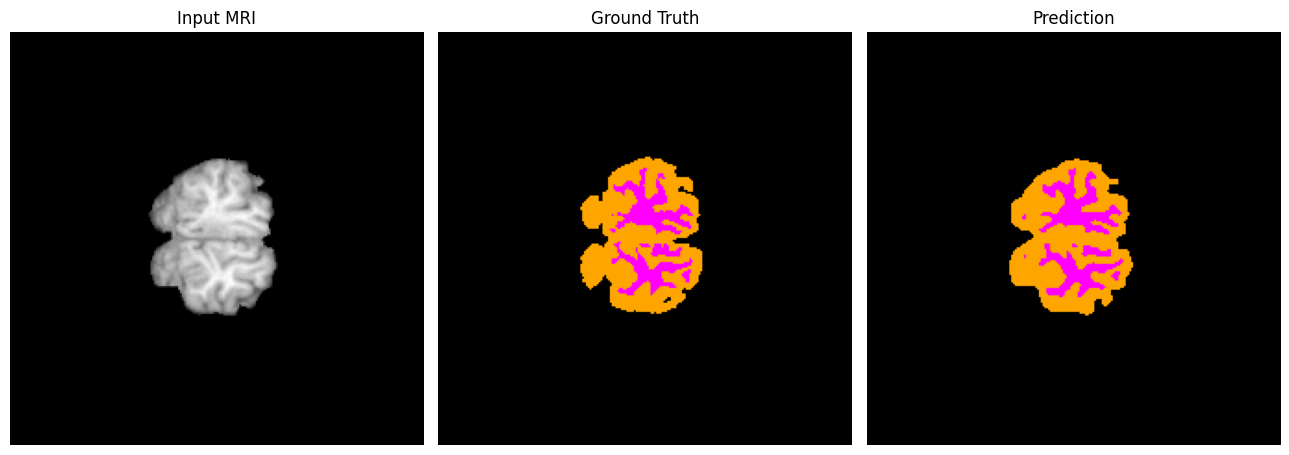

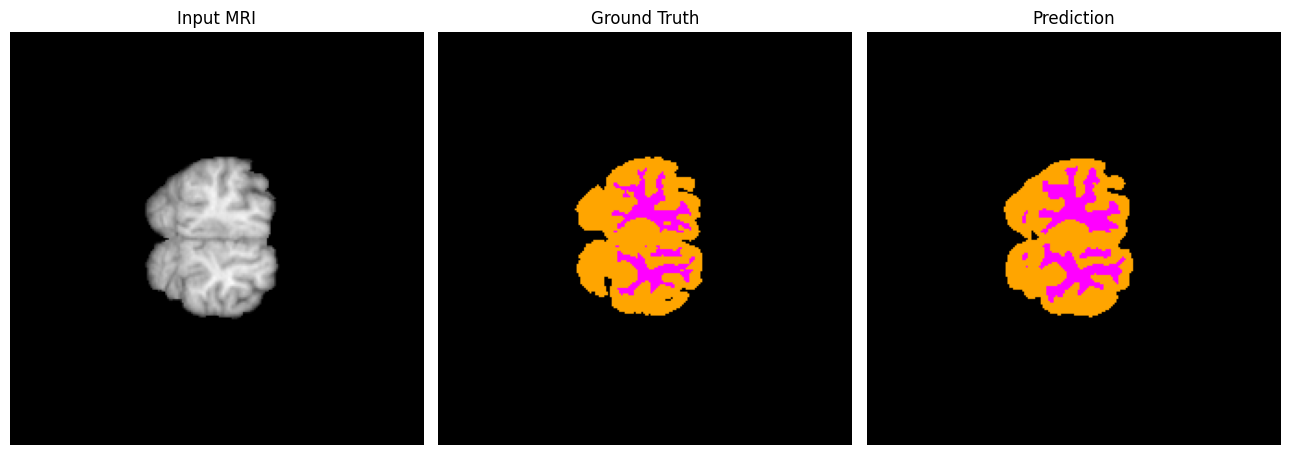

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass did not improve from 0.66215
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 566ms/step - csf_iou: 1.1701e-04 - dice_coefficient_multiclass: 0.4745 - gm_iou: 0.3689 - iou_score_multiclass: 0.3874 - loss: 0.6015 - pixel_accuracy_multiclass: 0.9956 - wm_iou: 0.2432 - val_csf_iou: 0.1799 - val_dice_coefficient_multiclass: 0.7482 - val_gm_iou: 0.7458 - val_iou_score_multiclass: 0.6591 - val_loss: 0.3176 - val_pixel_accuracy_multiclass: 0.9837 - val_wm_iou: 0.7423 - learning_rate: 5.0000e-05
Epoch 61/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - csf_iou: 0.1260 - dice_coefficient_multiclass: 0.7030 - gm_iou: 0.7171 - iou_score_multiclass: 0.6184 - loss: 0.3640 - pixel_accuracy_multiclass: 0.9862 - wm_iou: 0.6720
Epoch 61: val_iou_score_multiclass improved from 0.66215 to 0.66332, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 61: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

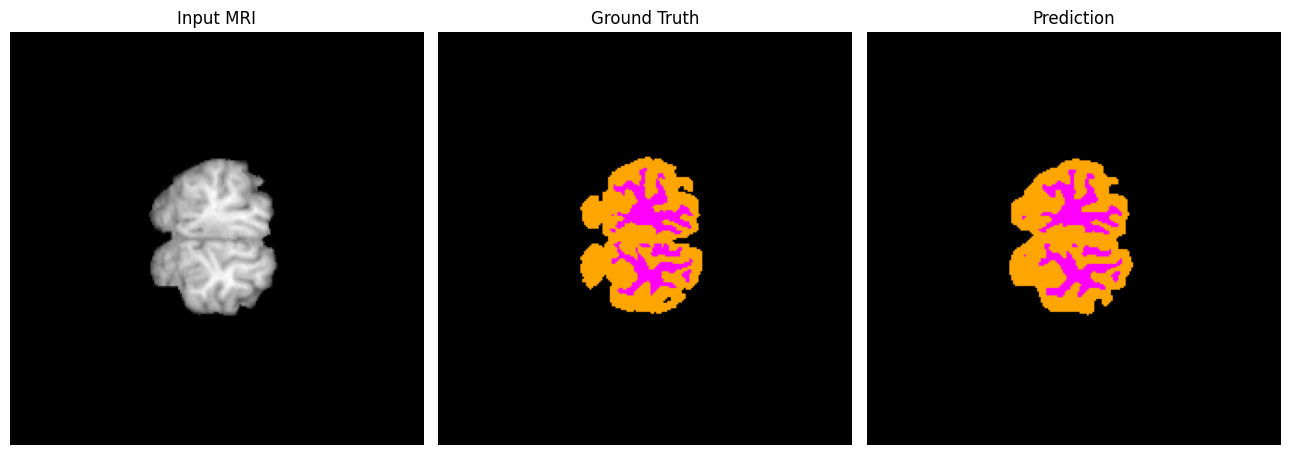

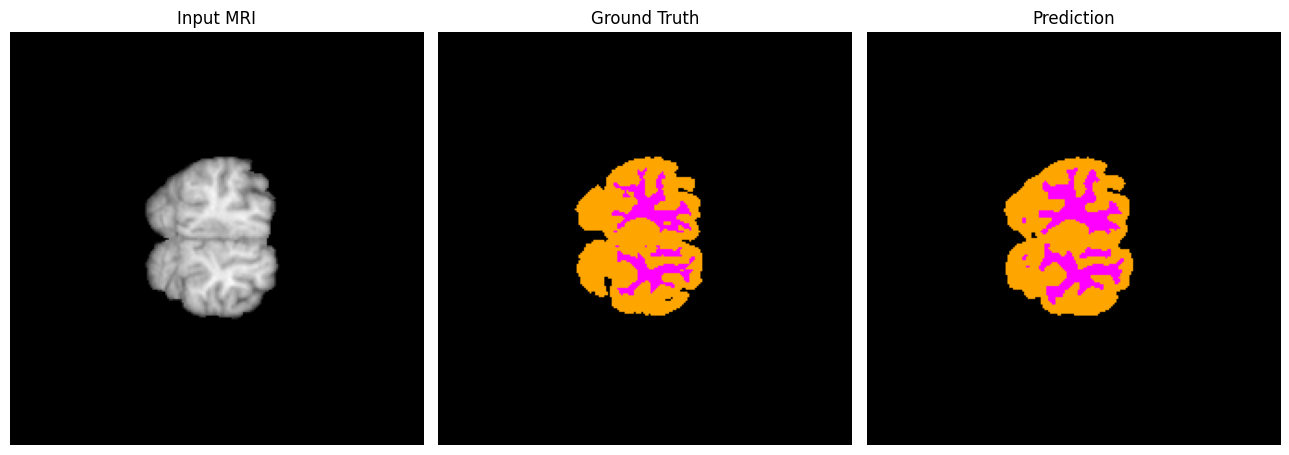

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.67273
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - csf_iou: 1.3134e-04 - dice_coefficient_multiclass: 0.4883 - gm_iou: 0.3902 - iou_score_multiclass: 0.4001 - loss: 0.5804 - pixel_accuracy_multiclass: 0.9958 - wm_iou: 0.2664 - val_csf_iou: 0.1999 - val_dice_coefficient_multiclass: 0.7597 - val_gm_iou: 0.7617 - val_iou_score_multiclass: 0.6713 - val_loss: 0.3021 - val_pixel_accuracy_multiclass: 0.9846 - val_wm_iou: 0.7519 - learning_rate: 5.0000e-05
Epoch 71/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - csf_iou: 0.1412 - dice_coefficient_multiclass: 0.7144 - gm_iou: 0.7332 - iou_score_multiclass: 0.6315 - loss: 0.3473 - pixel_accuracy_multiclass: 0.9870 - wm_iou: 0.6894
Epoch 71: val_iou_score_multiclass improved from 0.67273 to 0.67581, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 71: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━

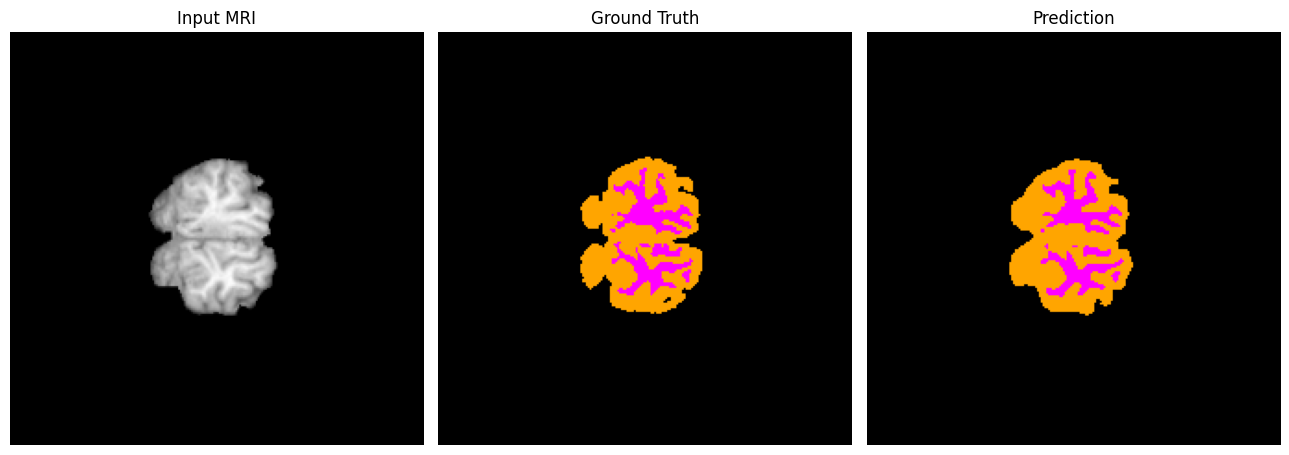

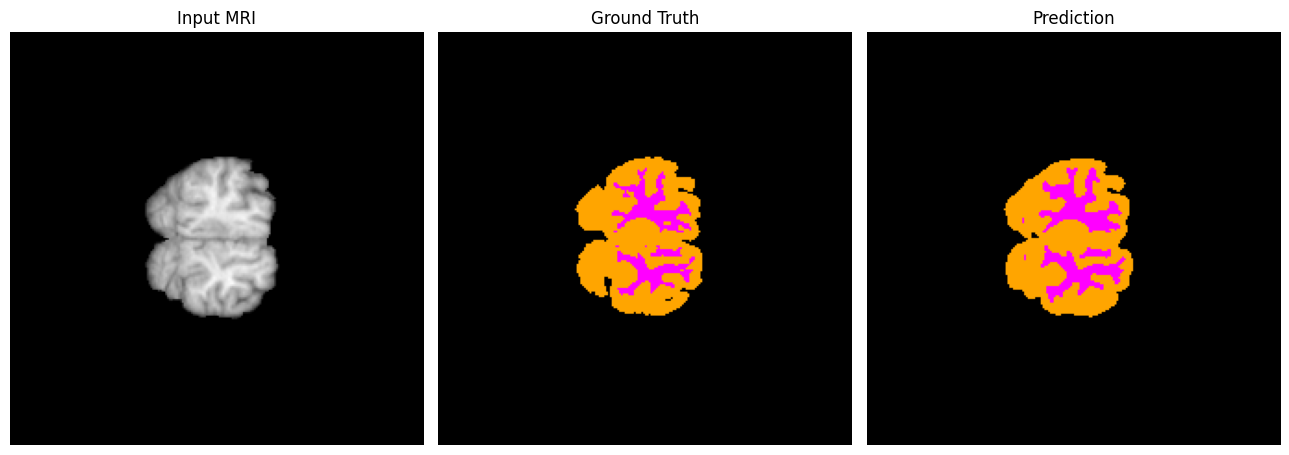

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass improved from 0.68564 to 0.68580, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 80: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 687ms/step - csf_iou: 1.4627e-04 - dice_coefficient_multiclass: 0.4981 - gm_iou: 0.4099 - iou_score_multiclass: 0.4097 - loss: 0.5648 - pixel_accuracy_multiclass: 0.9958 - wm_iou: 0.2798 - val_csf_iou: 0.2206 - val_dice_coefficient_multiclass: 0.7727 - val_gm_iou: 0.7799 - val_iou_score_multiclass: 0.6858 - val_loss: 0.2841 - val_pixel_accuracy_multiclass: 0.9858 - val_wm_iou: 0.7691 - learning_rate: 5.0000e-05
Epoch 81/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - csf_iou: 0.1562 - dice_coefficient_multiclass: 0.7238 - gm_iou: 0.7442 - iou_score_multiclass: 0.6419 - loss: 0.3344 - pixel_accuracy_multiclass: 0.9872 - wm_iou: 0.7015
Epoch 81: val_iou_score_multiclass improved from 0.68580 to 0.68585, saving model to best_

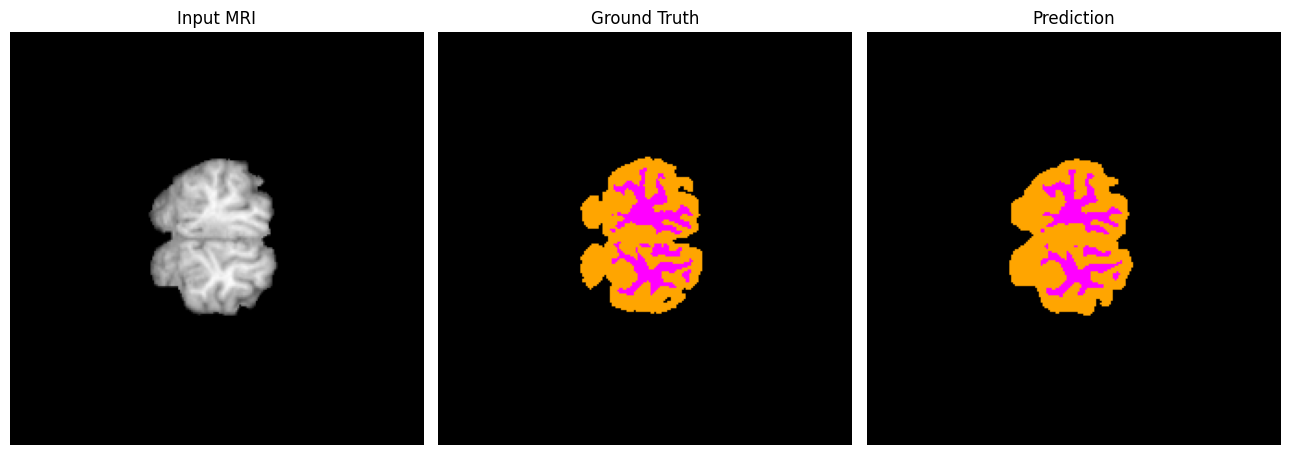

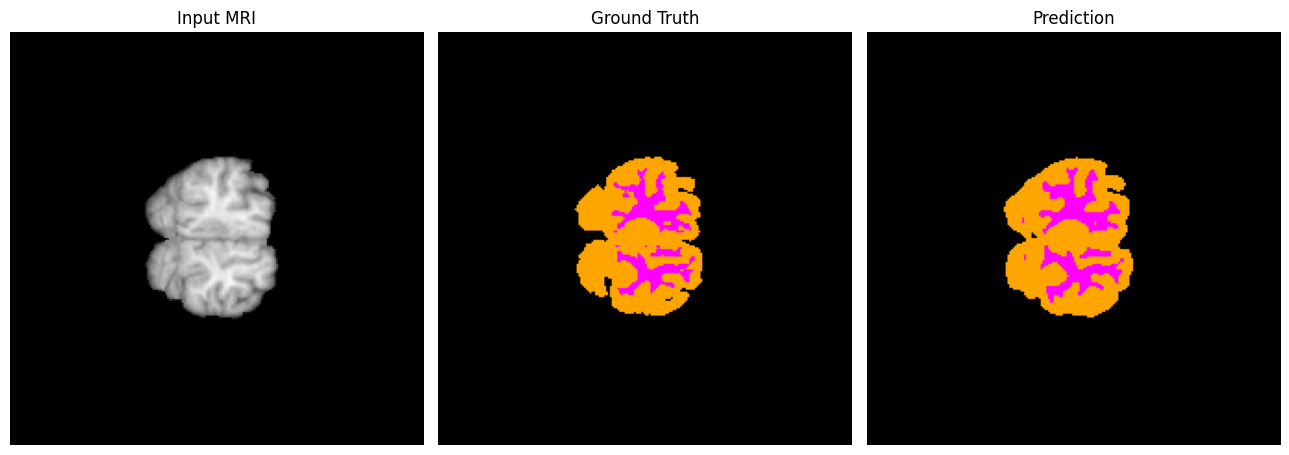

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass improved from 0.69524 to 0.69534, saving model to best_model_vgg16unetpp_multiclass_ibsr.keras

Epoch 90: finished saving model to best_model_vgg16unetpp_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 682ms/step - csf_iou: 1.6204e-04 - dice_coefficient_multiclass: 0.5089 - gm_iou: 0.4274 - iou_score_multiclass: 0.4200 - loss: 0.5489 - pixel_accuracy_multiclass: 0.9961 - wm_iou: 0.2995 - val_csf_iou: 0.2404 - val_dice_coefficient_multiclass: 0.7822 - val_gm_iou: 0.7897 - val_iou_score_multiclass: 0.6953 - val_loss: 0.2735 - val_pixel_accuracy_multiclass: 0.9864 - val_wm_iou: 0.7763 - learning_rate: 2.5000e-05
Epoch 91/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - csf_iou: 0.1717 - dice_coefficient_multiclass: 0.7320 - gm_iou: 0.7530 - iou_score_multiclass: 0.6510 - loss: 0.3228 - pixel_accuracy_multiclass: 0.9876 - wm_iou: 0.7112
Epoch 91: val_iou_score_multiclass did not improve from 0.69534
12/12 ━━━━━━━━━━━━━━━━━━━━

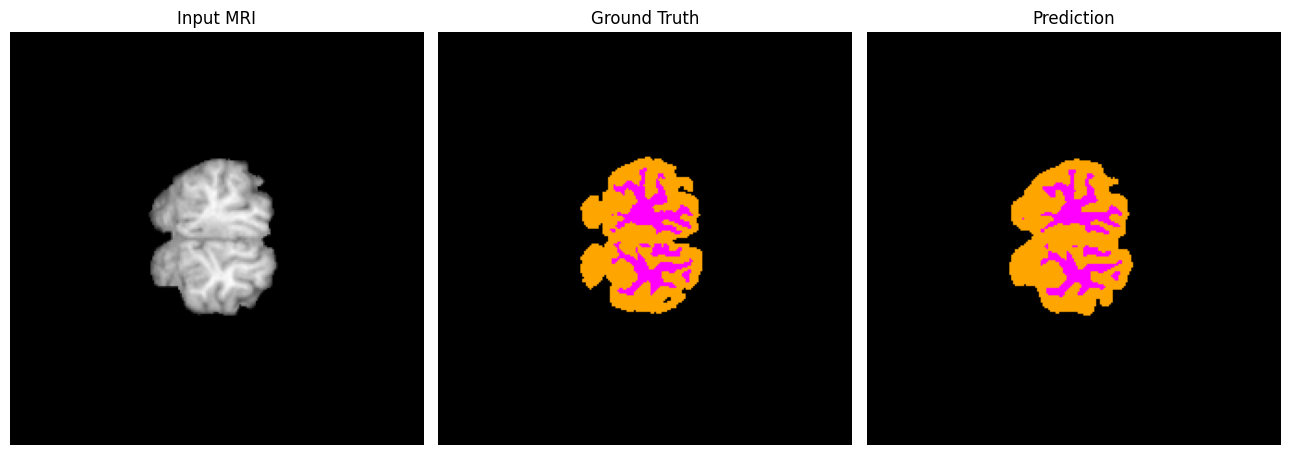

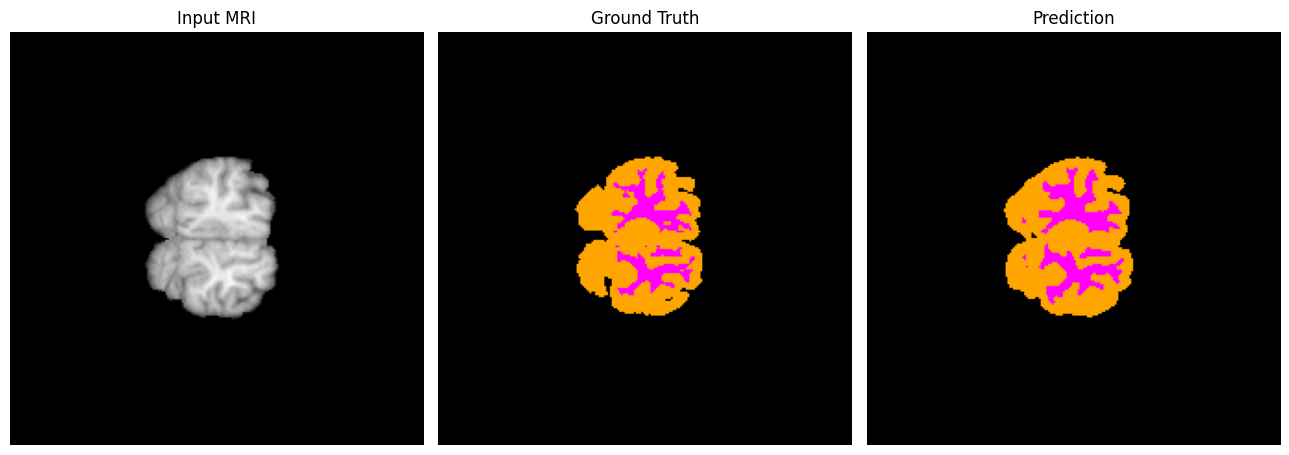

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.69781

Epoch 100: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 559ms/step - csf_iou: 1.7293e-04 - dice_coefficient_multiclass: 0.5149 - gm_iou: 0.4380 - iou_score_multiclass: 0.4258 - loss: 0.5411 - pixel_accuracy_multiclass: 0.9962 - wm_iou: 0.3098 - val_csf_iou: 0.2475 - val_dice_coefficient_multiclass: 0.7843 - val_gm_iou: 0.7874 - val_iou_score_multiclass: 0.6970 - val_loss: 0.2710 - val_pixel_accuracy_multiclass: 0.9862 - val_wm_iou: 0.7779 - learning_rate: 2.5000e-05

Training time: 20.5 min


In [15]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

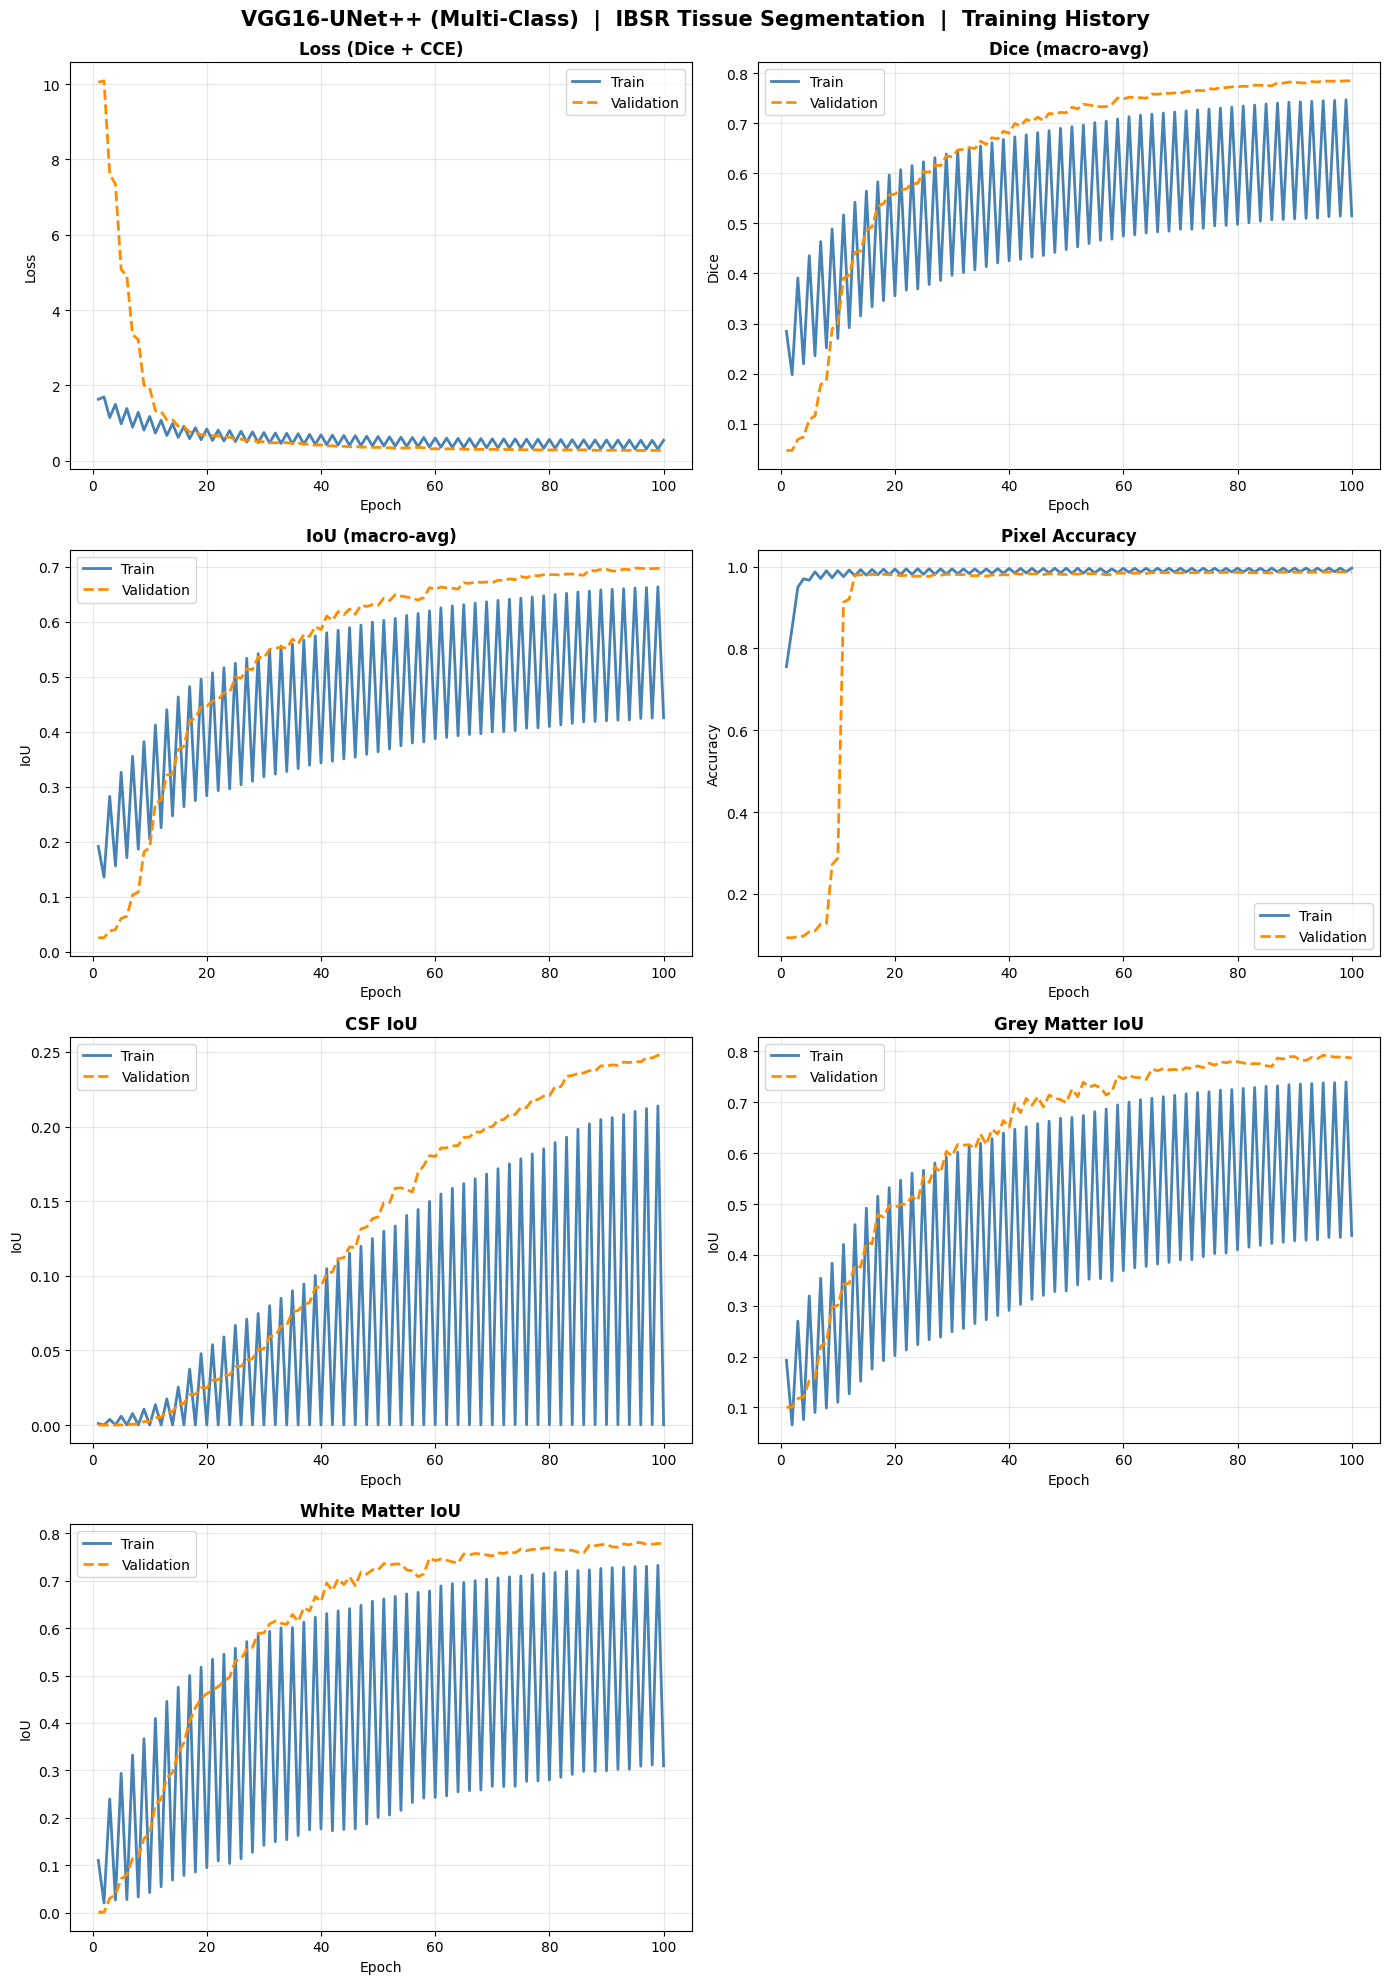

Plot saved ✓


In [16]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('VGG16-UNet++ (Multi-Class)  |  IBSR Tissue Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (train_key, val_key, title, ylabel) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train', color='steelblue', linewidth=2)
    ax.plot(epochs_range, H[val_key], label='Validation', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_vgg16unetpp_multiclass_ibsr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [17]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 70)
print('   BEST & AVERAGE METRICS  —  VGG16-UNet++ Multi-Class  |  IBSR')
print('=' * 70)
print(report.to_string())
print('=' * 70)

best_epoch_iou = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')

report

   BEST & AVERAGE METRICS  —  VGG16-UNet++ Multi-Class  |  IBSR
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.3090     0.6076    0.2703   0.9397
Dice (macro-avg)      0.7467     0.5408    0.7846   0.6419
IoU (macro-avg)       0.6638     0.4543    0.6978   0.5513
Pixel Accuracy        0.9962     0.9847    0.9866   0.8971
CSF IoU               0.2138     0.0596    0.2477   0.1298
Grey Matter IoU       0.7401     0.4642    0.7923   0.6309
White Matter IoU      0.7323     0.4003    0.7802   0.6075

Best Val IoU (macro-avg): 0.6978  (epoch 95)
Best Val CSF IoU         : 0.2477
Best Val Grey Matter IoU : 0.7923
Best Val White Matter IoU: 0.7802


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.3090,0.6076,0.2703,0.9397
Dice (macro-avg),0.7467,0.5408,0.7846,0.6419
IoU (macro-avg),0.6638,0.4543,0.6978,0.5513
Pixel Accuracy,0.9962,0.9847,0.9866,0.8971
CSF IoU,0.2138,0.0596,0.2477,0.1298
Grey Matter IoU,0.7401,0.4642,0.7923,0.6309
White Matter IoU,0.7323,0.4003,0.7802,0.6075


## 15. Load Best Model & Final Evaluation

In [18]:
best_model = tf.keras.models.load_model(
    'best_model_vgg16unetpp_multiclass_ibsr.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [19]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG16-UNet++ Multi-Class | IBSR)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model': 'VGG16-UNet++ Multi-Class (IBSR)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - csf_iou: 0.2186 - dice_coefficient_multiclass: 0.7788 - gm_iou: 0.8088 - iou_score_multiclass: 0.6959 - loss: 0.2732 - pixel_accuracy_multiclass: 0.9873 - wm_iou: 0.7804

2026-06-29 10:14:57.017493: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:14:57.262944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:14:58.413411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:14:58.671344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 10:14:59.738785: E external/local_xla/xla/stream_

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - csf_iou: 0.1627 - dice_coefficient_multiclass: 0.7350 - gm_iou: 0.7414 - iou_score_multiclass: 0.6530 - loss: 0.2846 - pixel_accuracy_multiclass: 0.9888 - wm_iou: 0.7318 

  FINAL TEST-SET METRICS  (VGG16-UNet++ Multi-Class | IBSR)
  loss                               : 0.2846
  compile_metrics                    : 0.7350


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
VGG16-UNet++ Multi-Class (IBSR),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

Test set predictions:


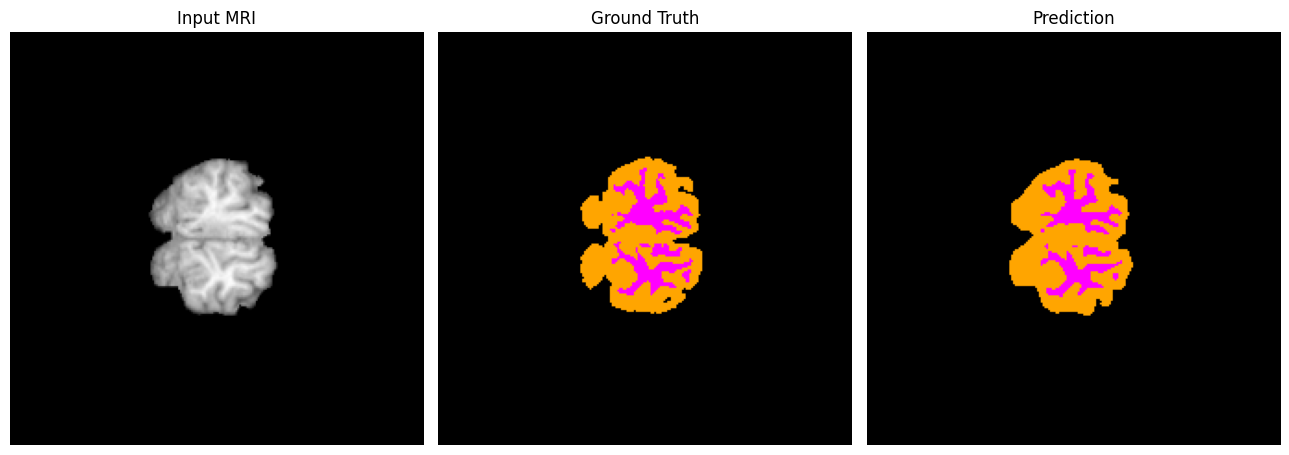

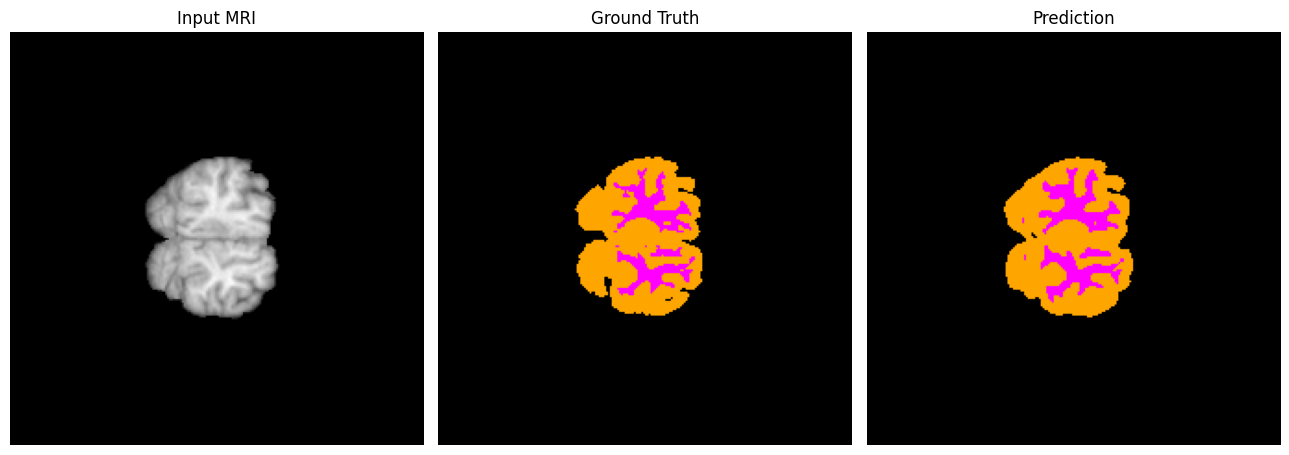

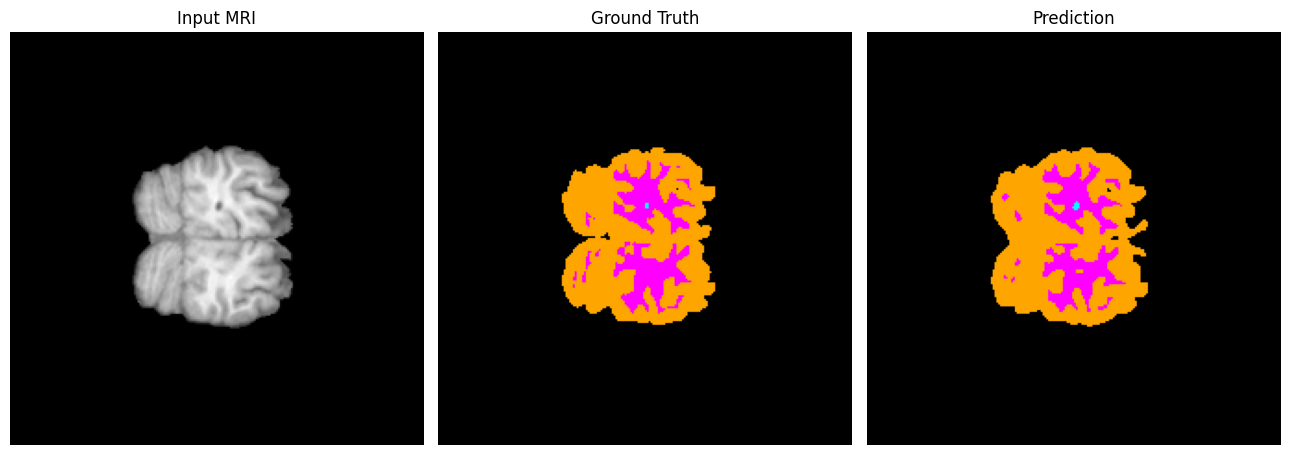

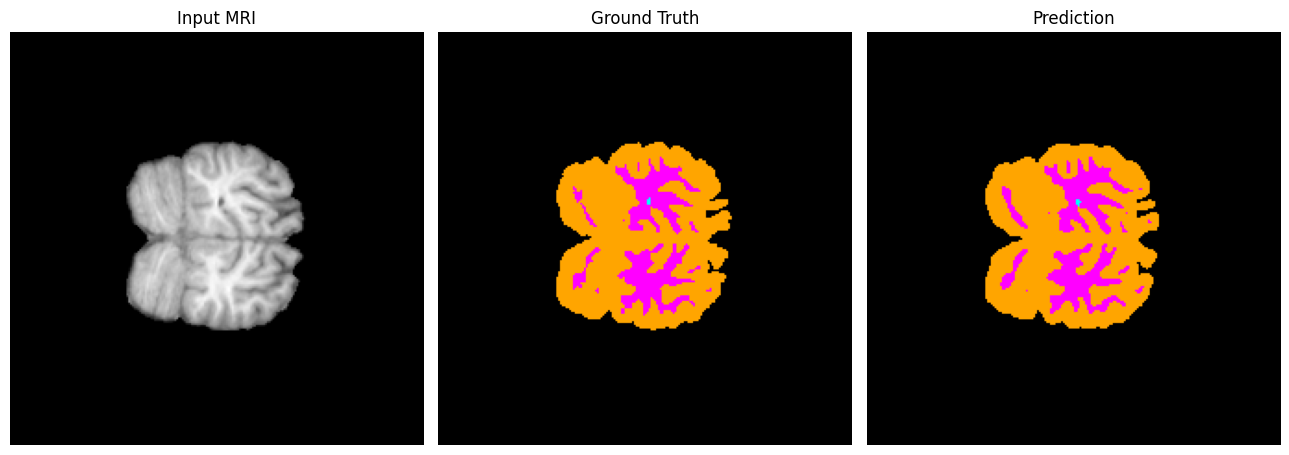

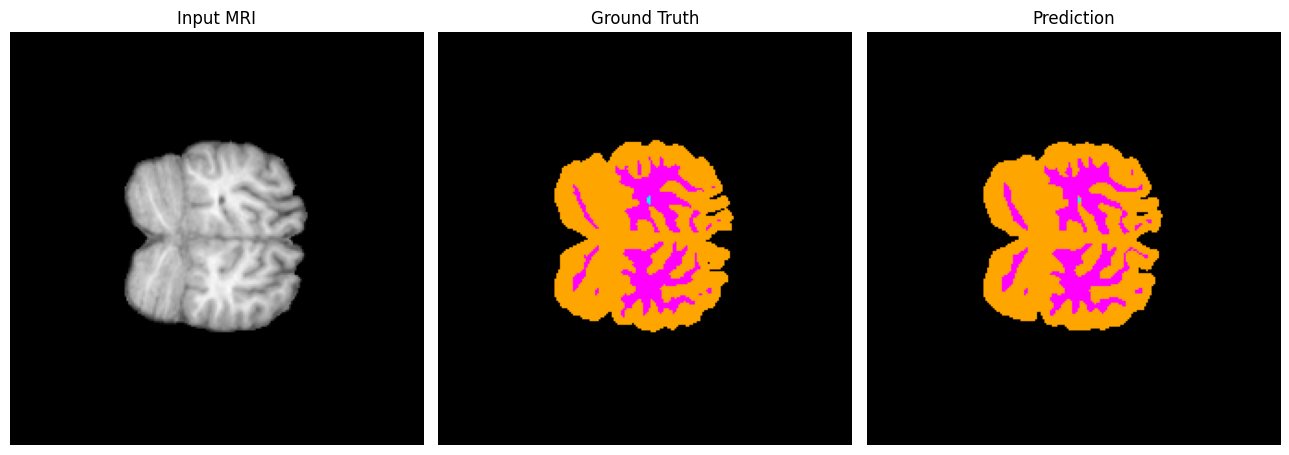

In [20]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [21]:
best_model.save('ibsr_vgg16_unetpp_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
